In [7]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Les modèles
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier # Le nouveau champion
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV

try:
    # Chargement
    data = joblib.load('processed_data.pkl')
    X_train = data['X_train']
    y_train = data['y_train']
    feature_names = data['feature_names'] # Indispensable pour l'interprétation

    print(f"✅ Données chargées.")
    print(f"X_train shape : {X_train.shape}")
    print(f"Nombre de variables : {len(feature_names)}")

except FileNotFoundError:
    print("❌ ERREUR : 'processed_data.pkl' est introuvable. Avez-vous fait l'étape 2 ?")

--- BLOC 1 : INITIALISATION ---
✅ Données chargées.
X_train shape : (129544, 1173)
Nombre de variables : 1173


In [8]:
# Modèle Dummmy qui prédit toujours la majorité
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
baseline_score = dummy.score(X_train, y_train)

print(f"Score de référence (Accuracy) : {baseline_score:.4f}")
print("Score to beat with our models !")

Score de référence (Accuracy) : 0.5000
Si vos modèles font moins que ça, c'est un échec. S'ils font plus, c'est une réussite.


In [9]:
print("Optimisation en cours (GridSearch)...")

lr = LogisticRegression(max_iter=1000, solver='liblinear')

# Grille d'hyperparamètres
param_grid_lr = {
    'C': [0.1, 1.0, 10.0],  # Force de régularisation
    'penalty': ['l1', 'l2'] # Type de nettoyage des variables inutiles
}

grid_lr = GridSearchCV(lr, param_grid_lr, cv=3, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)

print(f"✅ Meilleurs paramètres LR : {grid_lr.best_params_}")
print(f"✅ Meilleur score F1 (Validation) : {grid_lr.best_score_:.4f}")

Optimisation en cours (GridSearch)...
✅ Meilleurs paramètres LR : {'C': 10.0, 'penalty': 'l1'}
✅ Meilleur score F1 (Validation) : 0.6420


In [11]:
#Remplacement de KNN par Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)

# Optimisation des hyperparamètres (Tuning)
param_grid_dt = {
    'max_depth': [10, 20, 30, None],    # Profondeur max de l'arbre (pour éviter le par cœur)
    'min_samples_leaf': [10, 20, 50],   # Nombre min d'exemples par feuille (robustesse)
    'criterion': ['gini', 'entropy']    # La méthode de calcul de pureté
}

grid_dt = GridSearchCV(dt, param_grid_dt, cv=3, scoring='f1', n_jobs=1)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
print(f"✅ Meilleurs paramètres Arbre : {grid_dt.best_params_}")
print(f"✅ Meilleur score F1 (Validation) : {grid_dt.best_score_:.4f}")

✅ Meilleurs paramètres Arbre : {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 10}
✅ Meilleur score F1 (Validation) : 0.7660


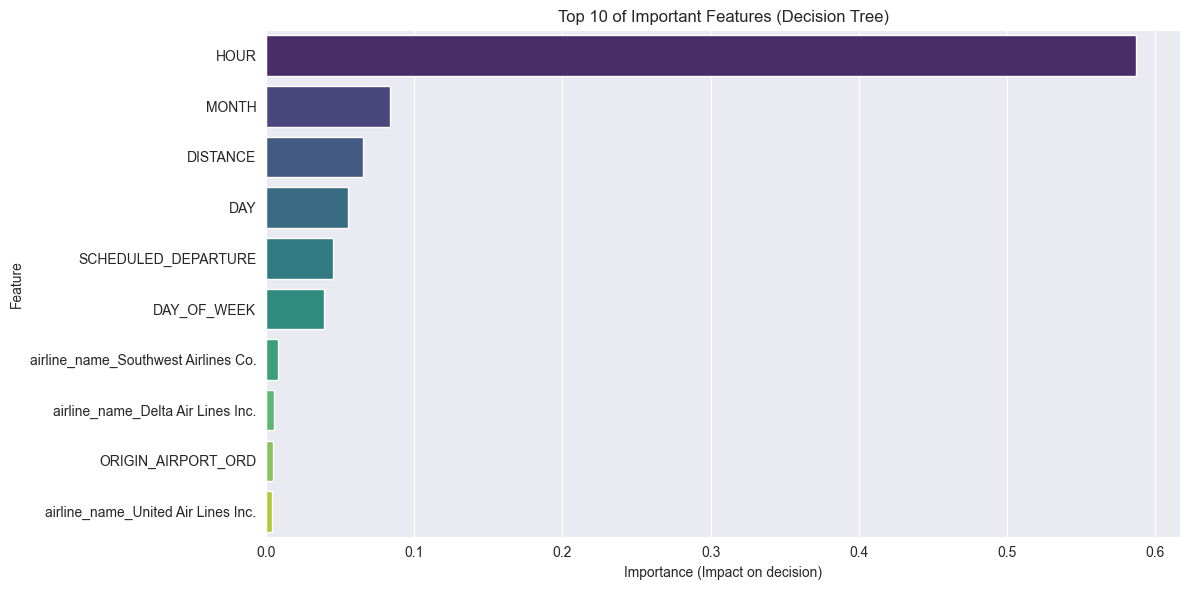

Top 3 most important features:
['HOUR' 'MONTH' 'DISTANCE']


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# On s'assure que le modèle est bien là
if 'best_dt' in locals() and hasattr(best_dt, 'feature_importances_'):
    importances = best_dt.feature_importances_

    # Vérification de sécurité (tailles correspondantes)
    if len(feature_names) == len(importances):
        # Création du tableau de données pour le graphique
        feat_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)

        # Affichage du TOP 10
        plt.figure(figsize=(12, 6))
        sns.barplot(
            x='Importance',
            y='Feature',
            hue='Feature', # Correction du warning récent de Seaborn
            data=feat_df.head(10),
            palette='viridis',
            legend=False
        )
        plt.title('Top 10 of Important Features (Decision Tree)')
        plt.xlabel('Importance (Impact on decision)')
        plt.tight_layout()
        plt.show()

        print("Top 3 most important features:")
        print(feat_df.head(3)['Feature'].values)
    else:
        print("Warning: Mismatch in feature names and importances length.")
        print("The graph will not be displayed.")
else:
    print("❌ Erreur : Le modèle 'best_dt' n'a pas été trouvé. Avez-vous lancé le Bloc 4 ?")

In [16]:
import joblib

try:
    # On sauvegarde les meilleurs estimateurs trouvés par le GridSearch
    joblib.dump(grid_lr.best_estimator_, 'model_lr.pkl')
    joblib.dump(grid_dt.best_estimator_, 'model_dt.pkl') # _dt pour Decision Tree

    print("✅ Succès ! Deux fichiers ont été créés :")
    print("   1. model_lr.pkl (Régression Logistique)")
    print("   2. model_dt.pkl (Arbre de Décision)")
    print("\n👉 Vous pouvez maintenant passer au dernier fichier : 4_Evaluation.ipynb")

except NameError:
    print("❌ Erreur : Les modèles 'grid_lr' ou 'grid_dt' n'existent pas.")
    print("Assurez-vous d'avoir exécuté les Blocs 3 et 4 avant celui-ci.")

✅ Succès ! Deux fichiers ont été créés :
   1. model_lr.pkl (Régression Logistique)
   2. model_dt.pkl (Arbre de Décision)

👉 Vous pouvez maintenant passer au dernier fichier : 4_Evaluation.ipynb
